# 1. Выбор датасета.

The total number of records in the dataset is 1436 cars. Description of each of variables is as below:

Columns:
- Id: Unique identifier for each car entry.
- Model: The model name of the Toyota Corolla.
- Price: The selling price of the used car.
- Age_08_04: The age of the car in months as of August 2004.
- Mfg_Month: The manufacturing month of the car.
- Mfg_Year: The manufacturing year of the car.
- KM: The number of kilometers the car has been driven.
- Fuel_type: The type of fuel the car uses (e.g., Petrol, Diesel).
- HP: Horsepower, a measure of the engine's power.
- Met_Color: Binary indicator for metallic paint (0 = No, 1 = Yes).
- Color: The exterior color of the car.
- Automatic: Binary indicator for automatic transmission (0 = No, 1 = Yes).
- CC: Engine size in cubic centimeters.
- Doors: Number of doors on the car.
- Cylinders: Number of cylinders in the engine.
- Gears: Number of gears in the transmission.
- Quarterly: Quarterly tax for the car.
- Weight: Weight of the car.
- Mfr_Guarantee: Binary indicator for manufacturer's guarantee (0 = No, 1 = Yes).
- BOVAG_Guarantee: Binary indicator for BOVAG guarantee (0 = No, 1 = Yes).
- Guarantee_Period: Duration of the guarantee in months.
- ABS: Binary indicator for Anti-lock Braking System (0 = No, 1 = Yes).
- Airbag_1: Binary indicator for the presence of Airbag 1 (0 = No, 1 = Yes).
- Airbag_2: Binary indicator for the presence of Airbag 2 (0 = No, 1 = Yes).
- Airco: Binary indicator for air conditioning (0 = No, 1 = Yes).
- Automatic_airco: Binary indicator for automatic air conditioning (0 = No, 1 = Yes).
- Boardcomputer: Binary indicator for a board computer (0 = No, 1 = Yes).
- CD_Player: Binary indicator for the presence of a CD player (0 = No, 1 = Yes).
- Central_Lock: Binary indicator for central locking system (0 = No, 1 = Yes).
- Powered_Windows: Binary indicator for powered windows (0 = No, 1 = Yes).
- Power_Steering: Binary indicator for power steering (0 = No, 1 = Yes).
- Radio: Binary indicator for a radio (0 = No, 1 = Yes).
- Mistlamps: Binary indicator for mist lamps (0 = No, 1 = Yes).
- Sport_Model: Binary indicator for a sport model (0 = No, 1 = Yes).
- Backseat_Divider: Binary indicator for a backseat divider (0 = No, 1 = Yes).
- Metallic_Rim: Binary indicator for metallic rims (0 = No, 1 = Yes).
- Radio_cassette: Binary indicator for a radio cassette player (0 = No, 1 = Yes).
- Parking_Assistant: Binary indicator for a parking assistant (0 = No, 1 = Yes).
- Tow_Bar: Binary indicator for the presence of a tow bar (0 = No, 1 = Yes).

# 2. Первичный анализ данных (EDA) и предобработка.

In [303]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas
import numpy as np
from sklearn.preprocessing import TargetEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from scipy.stats import kstest, norm

In [304]:
df = pandas.read_csv('ToyotaCorolla.csv')
df

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1431,1438,TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors,7500,69,12,1998,20544,Petrol,86,1,...,1,1,0,1,1,1,0,0,0,0
1432,1439,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,10845,72,9,1998,19000,Petrol,86,0,...,0,1,0,0,1,1,0,0,0,0
1433,1440,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,8500,71,10,1998,17016,Petrol,86,0,...,0,1,0,0,0,1,0,0,0,0
1434,1441,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,7250,70,11,1998,16916,Petrol,86,1,...,0,0,0,0,0,1,0,0,0,0


In [305]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 1436 non-null   int64
 1   Model              1436 non-null   str  
 2   Price              1436 non-null   int64
 3   Age_08_04          1436 non-null   int64
 4   Mfg_Month          1436 non-null   int64
 5   Mfg_Year           1436 non-null   int64
 6   KM                 1436 non-null   int64
 7   Fuel_Type          1436 non-null   str  
 8   HP                 1436 non-null   int64
 9   Met_Color          1436 non-null   int64
 10  Color              1436 non-null   str  
 11  Automatic          1436 non-null   int64
 12  CC                 1436 non-null   int64
 13  Doors              1436 non-null   int64
 14  Cylinders          1436 non-null   int64
 15  Gears              1436 non-null   int64
 16  Quarterly_Tax      1436 non-null   int64
 17  Weight             1436 n

In [306]:
print("Кол-во записей:\n", df.count())
print("\nСтатистика:\n", df.describe(include="all"))
print("\nКол-во пропусков данных:\n", df.isnull().sum())

Кол-во записей:
 Id                   1436
Model                1436
Price                1436
Age_08_04            1436
Mfg_Month            1436
Mfg_Year             1436
KM                   1436
Fuel_Type            1436
HP                   1436
Met_Color            1436
Color                1436
Automatic            1436
CC                   1436
Doors                1436
Cylinders            1436
Gears                1436
Quarterly_Tax        1436
Weight               1436
Mfr_Guarantee        1436
BOVAG_Guarantee      1436
Guarantee_Period     1436
ABS                  1436
Airbag_1             1436
Airbag_2             1436
Airco                1436
Automatic_airco      1436
Boardcomputer        1436
CD_Player            1436
Central_Lock         1436
Powered_Windows      1436
Power_Steering       1436
Radio                1436
Mistlamps            1436
Sport_Model          1436
Backseat_Divider     1436
Metallic_Rim         1436
Radio_cassette       1436
Parking_Assistant    

In [307]:
print('Model: ', df['Model'].unique().size)
print('Fuel_Type: ', df['Fuel_Type'].unique().size)
print('Color: ', df['Color'].unique().size)

Model:  319
Fuel_Type:  3
Color:  10


In [308]:
df['Mfg_Year'].unique()

array([2002, 2003, 2004, 2001, 2000, 1999, 1998])

# 3. Работа с признаками (Feature Engineering).

Установим столбец Id как id датасета.

In [309]:
df.set_index("Id", inplace=True)
df.head()

,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
Id,,,,,,,,,,,,,,,,,,,,,
1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,Blue,...,1,1,0,0,0,1,0,0,0,0
2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,Silver,...,0,1,0,0,0,1,0,0,0,0
3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,Blue,...,0,1,0,0,0,1,0,0,0,0
4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,Black,...,0,1,0,0,0,1,0,0,0,0
5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,Black,...,1,1,0,1,0,1,0,0,0,0


У нас очень мало уникальных значений Mfg_Year. Можно просто отнять от всех значений минимальное значение (1998), чтобы не энкодить. Но есть предположение, что этот признак сильно скоррелирован с Age_08_04, как и Mfg_Month. Поэтому стоит проверить на тепловой карте эти предположения и при необходимости просто удалить эти столбцы.

Также по матрице корреляций стоит проверить предположение о корреляции столбцов 'Color' и 'Met_Color', так как непонятно, что именно значит металлический цвет и почему он не занесен в столбец 'Color', если это такой же цвет, как и все остальные.

Для столбца Model лучше всего будет применить Target Encoding, так как в этом столбце много уникальных значений (высокая кардильность) и класс машины (а определенная модель принадлежит к определенному классу) непосредственно влияет на цену. Но если применить Target Encoding на неразделенном датасете, то модель может переобучиться. Поэтому оставим это тоже на потом. Модель не будет бояться новых моделей авто, так как все энкодеры из category_encoders новой модели присваивают глобальное среднее по всему датасету. Так как моделей очень много, мы не можем поставить стратификацию и быть уверенными в адекватности и хотя бы примерном соответствии цен из тренировочного и тестового датасета. Поэтому примерним сглаживание, которое будет в степени, зависящей от частоты встречаемости модели в датасете, подмешивать среднее по цене модели к глобальному среднему цены автомобилей.

Для столбца Fuel_Type можно применить One Hot Encoding, так как всего 3 уникальных значения, что несильно увеличит размерность пространства.

Перед тем как энкодить столбец Color, стоит проверить, стоит ли его вообще оставлять. Для этого вычислим корреляционное отношение для этого столбца.

In [310]:
mean_global = df['Price'].mean()
group_stats = df.groupby('Color')['Price'].agg(['count', 'mean'])
bss = (group_stats['count'] * (group_stats['mean'] - mean_global)**2).sum()
tss = ((df['Price'] - mean_global)**2).sum()
np.sqrt(bss / tss)

np.float64(0.23362468083663335)

Корреляционное отношение равно 0.2336, это не сильно маленькое значение, так что можно оставить столбец Color. Столбец Color хоть и имеет 10 категорий, что сильно увеличивает размерность пространства, но лучше всего к нему применить One Hot Encoding, так как никакой зависимости между категориями нет, а значит не применить Label Encoding. Target Encoding и Feature Hashing не применить, так как Target Encoding даст рандомные значения, так какцвет скорее всего слабо скоррелирован с ценой, а Feature Hashing будет бесполезен по этой же причине.

In [311]:
df1 = df.copy().drop(['Color'], axis=1)
df = pandas.get_dummies(df, columns=['Color'], drop_first=True, dtype=int)

Аналогично для столбца Fuel_Type.

In [312]:
mean_global = df['Price'].mean()
group_stats = df.groupby('Fuel_Type')['Price'].agg(['count', 'mean'])
bss = (group_stats['count'] * (group_stats['mean'] - mean_global)**2).sum()
tss = ((df['Price'] - mean_global)**2).sum()
np.sqrt(bss / tss)

np.float64(0.06581546560274948)

Столбец Fuel_Type слабо скоррелирован с целевой переменной, значит его можно удалить.

In [313]:
df = df.drop(['Fuel_Type'], axis=1)
df1 = df1.drop(['Fuel_Type'], axis=1)

Построим матрицу корреляций.

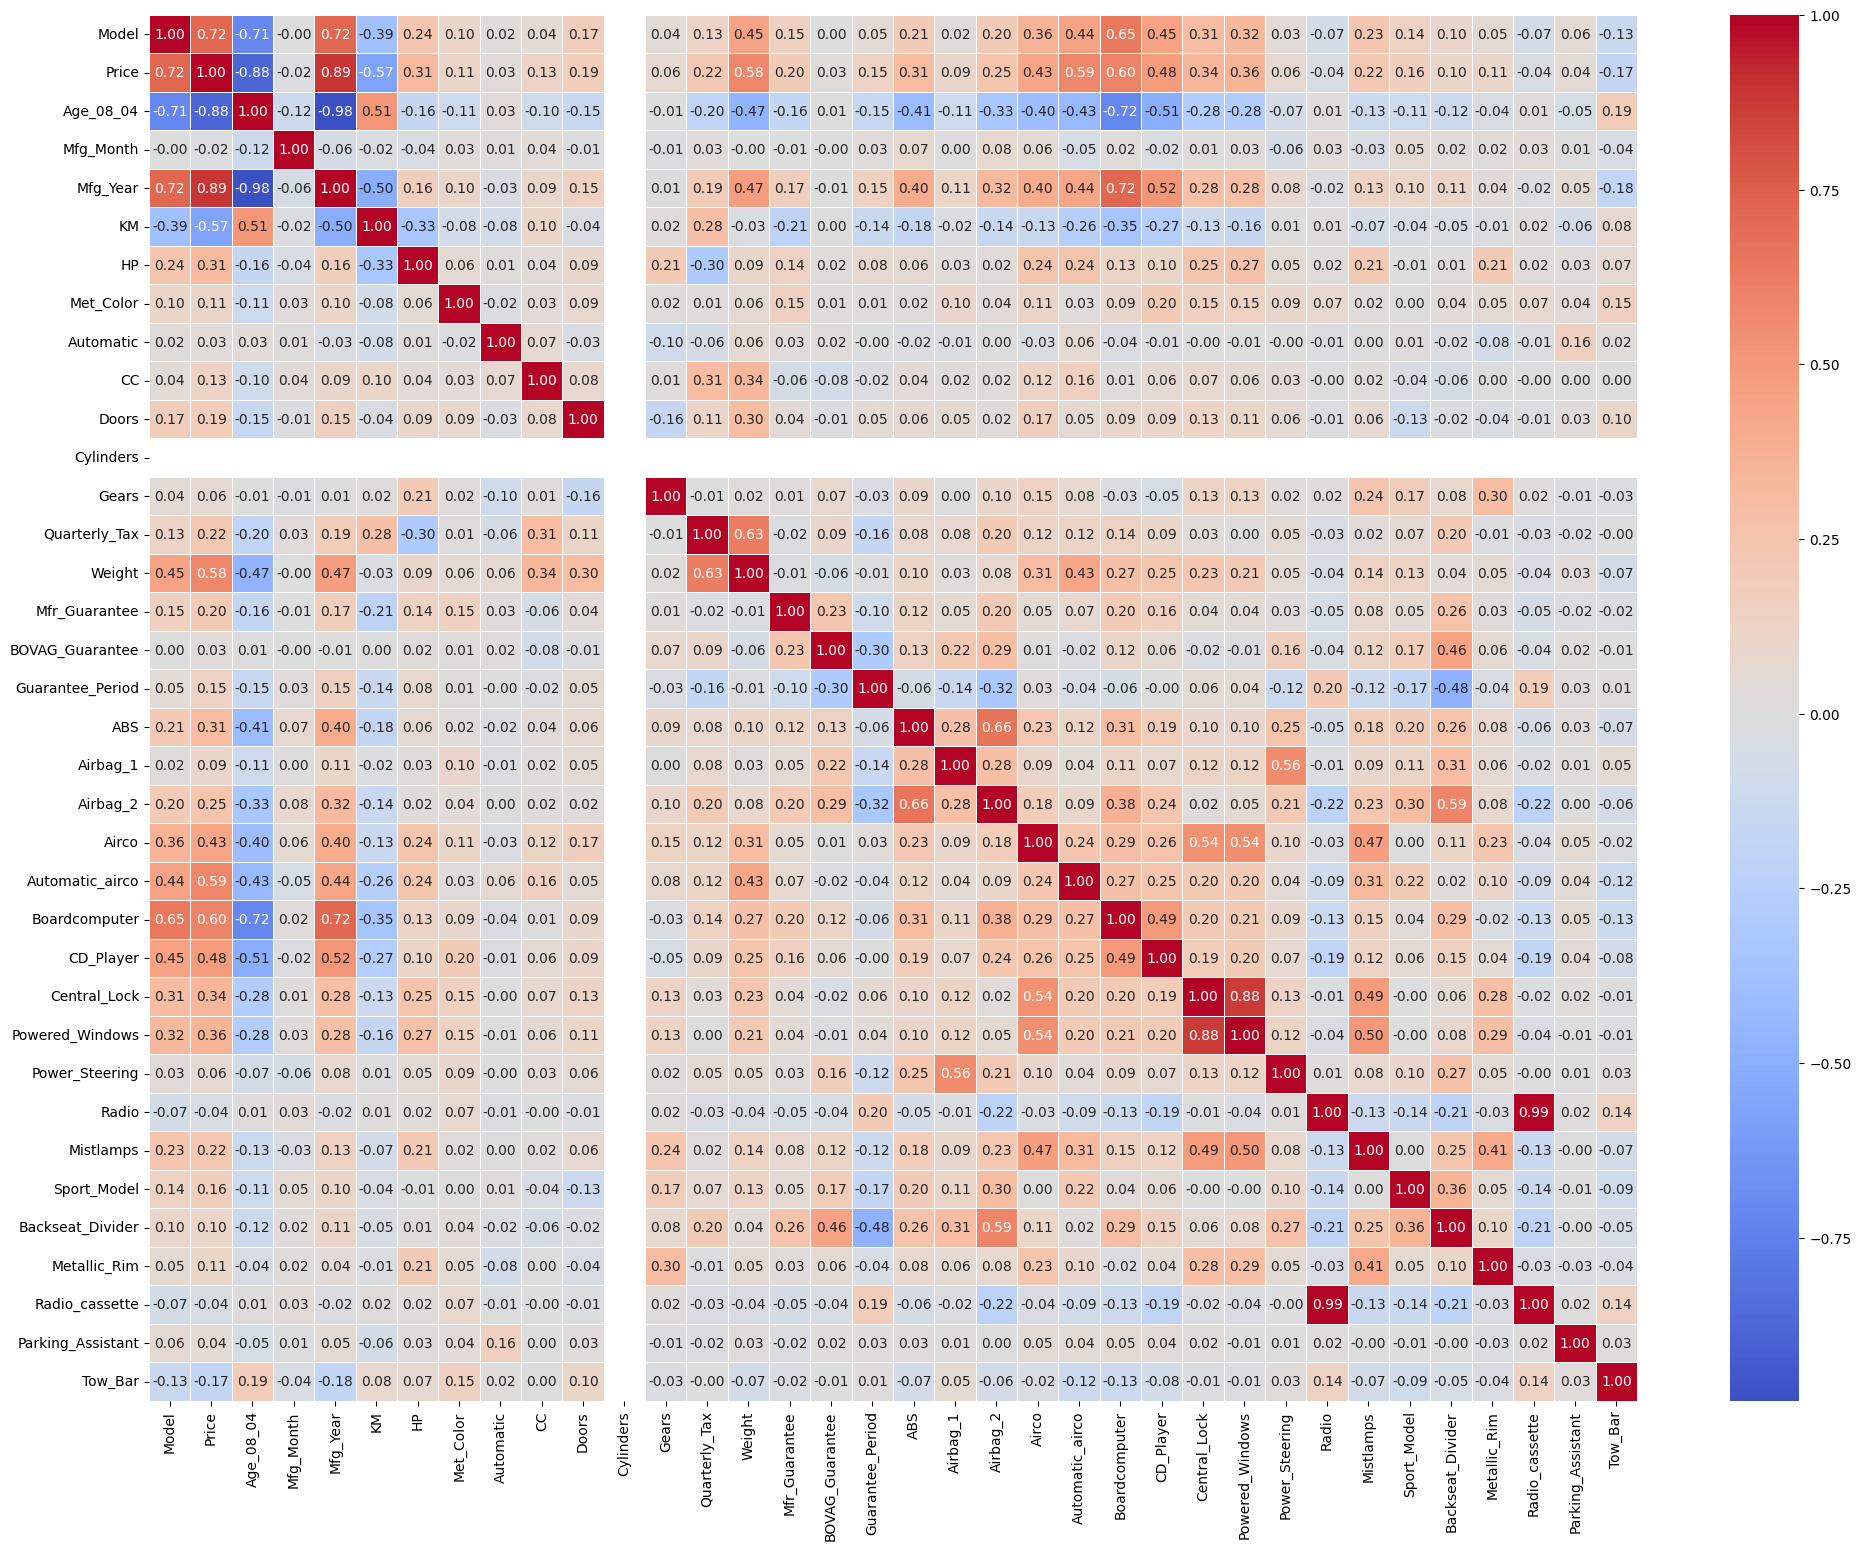

In [314]:
encoder = TargetEncoder(target_type="continuous")
df1['Model'] = encoder.fit_transform(df1[['Model']], df1['Price'])

corr_matrix = df1.corr()

plt.figure(figsize=(24, 18))

sns.heatmap(corr_matrix, 
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=0.5)

plt.show()

In [315]:
df1['Cylinders'].unique()

array([4])

Удаляем колонку 'Cylinders', так как в ней только 1 значение. Удаляем колонки 'Mfg_Month' и 'Mfg_Year'. Удаляем столбцы, которые мало влияют на целевую переменную, а именно: 'Automatic', 'Gears', 'BOVAG_Guarantee', 'Power_Steering', 'Radio', 'Radio_cassette', 'Parking_Assistant'. Признаки 'Central_Lock' и 'Powered_Windows' имеют довольно высокую корреляцию, поэтому удаляем тот, который меньше коррелирует с целевой переменной, а именно 'Central_Lock'.

In [316]:
df = df.drop(['Cylinders', 'Mfg_Month', 'Mfg_Year', 'Automatic', 'Gears', 'BOVAG_Guarantee', 'Power_Steering', 'Radio', 'Radio_cassette', 'Parking_Assistant', 'Central_Lock'], axis=1)
df1 = df1.drop(['Cylinders', 'Mfg_Month', 'Mfg_Year', 'Automatic', 'Gears', 'BOVAG_Guarantee', 'Power_Steering', 'Radio', 'Radio_cassette', 'Parking_Assistant', 'Central_Lock'], axis=1)

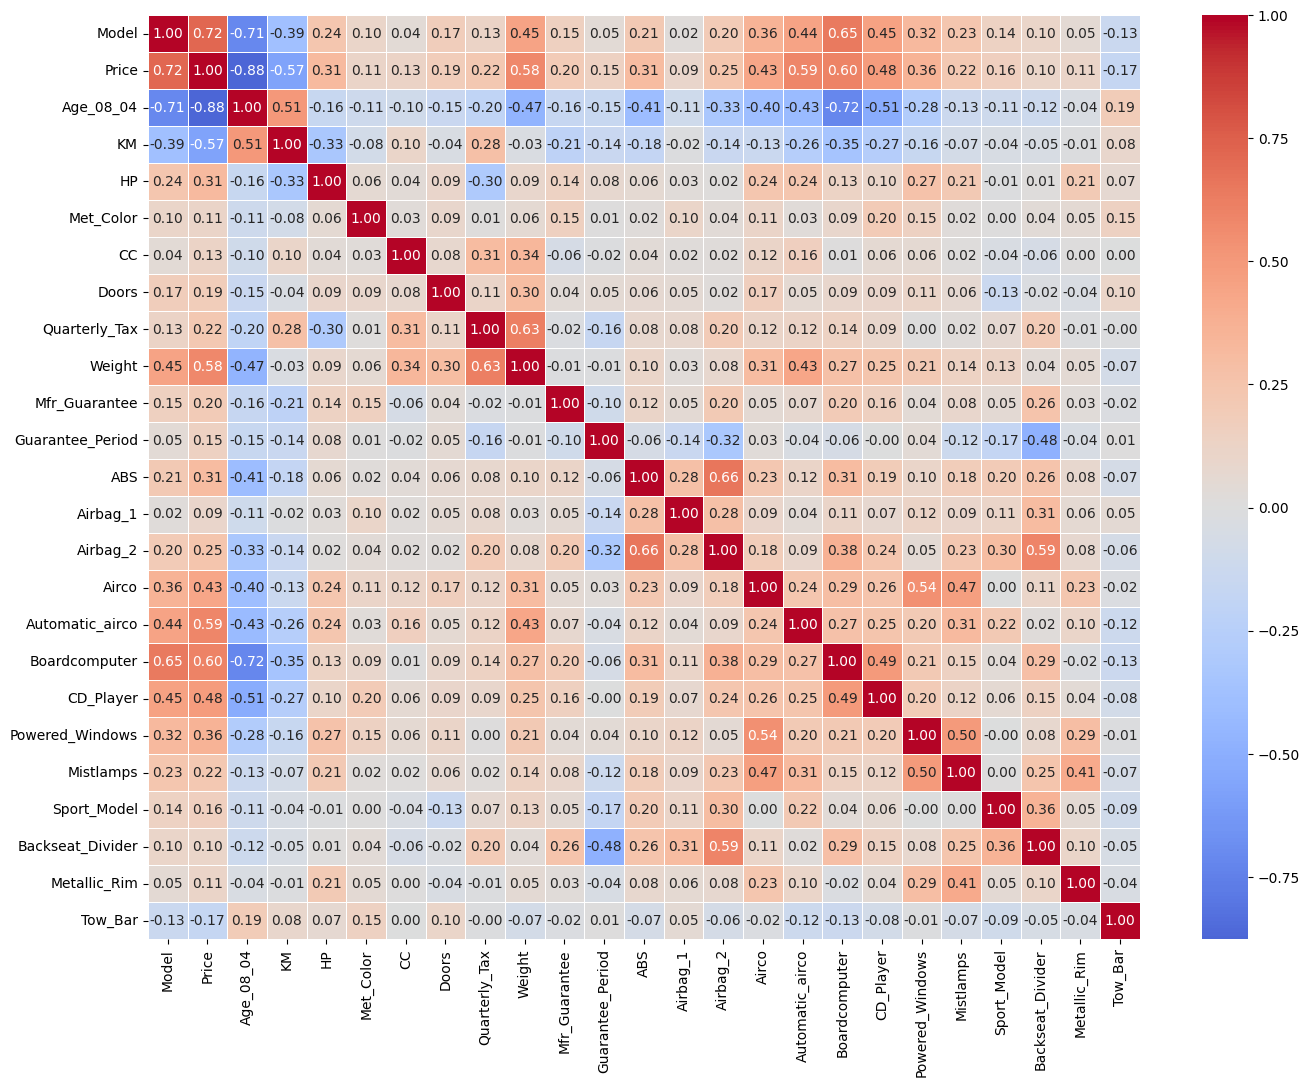

In [317]:
corr_matrix = df1.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(corr_matrix, 
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=0.5)

plt.show()

Проверим наш датасет на аномальные выбросы.

In [318]:
num_df = df.select_dtypes(include=['number'])
statistics = pandas.DataFrame(columns=num_df.columns)
statistics.loc['skewness'] = num_df.skew()     # Асимметрия
statistics.loc['kurtosis'] = num_df.kurt()     # Эксцесс
statistics.T

,skewness,kurtosis
Price,1.703885,3.737781
Age_08_04,-0.826702,-0.076632
KM,1.015912,1.685057
HP,0.955836,8.836434
Met_Color,-0.747029,-1.443961
CC,27.431793,930.711227
Doors,-0.076395,-1.874765
Quarterly_Tax,1.993834,4.298345
Weight,3.108639,19.362901
Mfr_Guarantee,0.368588,-1.866745


Построим BoxPlot'ы признаков, у которых большая ассиметрия или эксцесс.

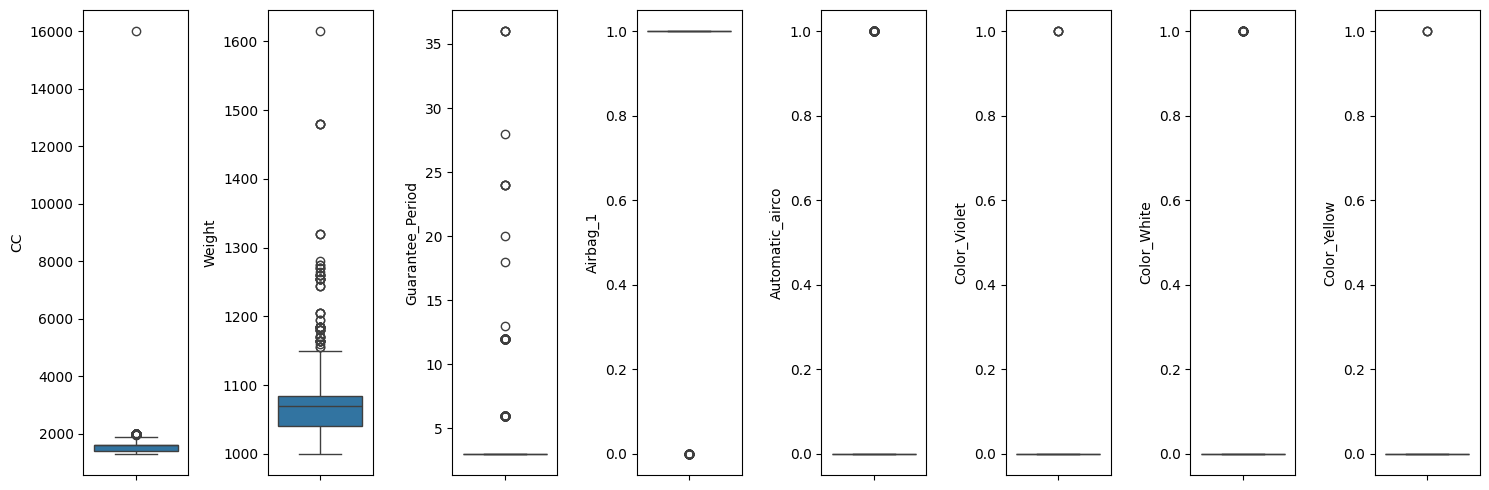

In [319]:
fig, axes = plt.subplots(1, 8, figsize=(15, 5))
axes = axes.flatten()

sns.boxplot(data=df, y='CC', ax=axes[0])
sns.boxplot(data=df, y='Weight', ax=axes[1])
sns.boxplot(data=df, y='Guarantee_Period', ax=axes[2])
sns.boxplot(data=df, y='Airbag_1', ax=axes[3])
sns.boxplot(data=df, y='Automatic_airco', ax=axes[4])
sns.boxplot(data=df, y='Color_Violet', ax=axes[5])
sns.boxplot(data=df, y='Color_White', ax=axes[6])
sns.boxplot(data=df, y='Color_Yellow', ax=axes[7])

plt.tight_layout()

In [320]:
df[df['CC'] > 15000]

,Model,Price,Age_08_04,KM,HP,Met_Color,CC,Doors,Quarterly_Tax,Weight,...,Tow_Bar,Color_Black,Color_Blue,Color_Green,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow
Id,,,,,,,,,,,,,,,,,,,,,
81,TOYOTA Corolla 1.6 5drs 1 4/5-Doors,18950,25,20019,110,1,16000,5,100,1180,...,0,0,1,0,0,0,0,0,0,0


Явно в таком автомобиле не будет двигателя такого объема. Об этом нам также говорит и 1.6 в названии авто. Так что это опечатка, исправим.

In [321]:
df.loc[df['CC'] > 15000, 'CC'] = 1600

В признаке Weights видим много выбросов, длинный хвост. Попробуем прологарифмировать. 

<Axes: ylabel='Weight'>

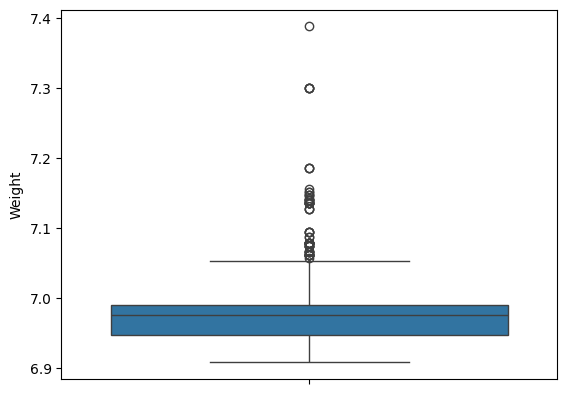

In [322]:
df['Weight'] = np.log1p(df['Weight'])
sns.boxplot(data=df, y='Weight')

В остальных признаках я не вижу ничего аномального. Теперь посмотрим BoxPlot целевой переменной.

<Axes: ylabel='Price'>

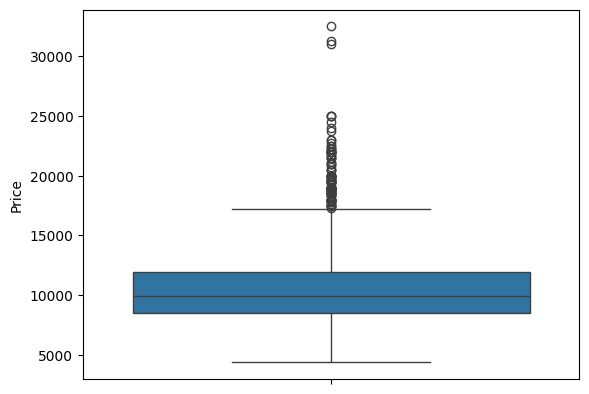

In [323]:
sns.boxplot(data=df, y='Price')

Здесь мы опять видим много выбросов и тяжелые хвосты. Надо логарифмировать.

<Axes: ylabel='Price'>

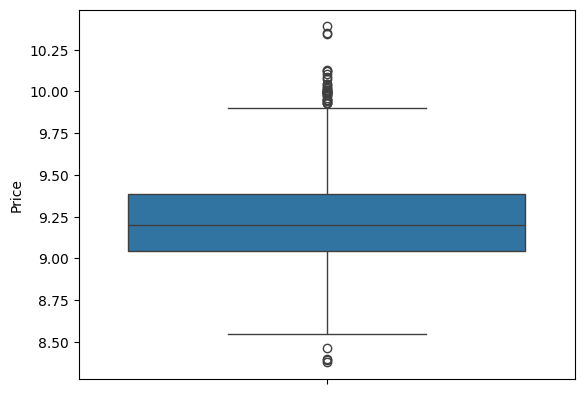

In [324]:
df['Price'] = np.log1p(df['Price'])
sns.boxplot(data=df, y='Price')

Теперь важно после предсказаний не забывать все переводить обратно. При оценке модели аналогично.

# 4. Разделение выборки.

Разделим выборку на параметры и целевую переменную.

In [325]:
X = df.copy().drop(["Price"], axis=1)
y = df["Price"].copy()

Далее разделим данные на train и test.

In [326]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)
y_test = np.expm1(y_test)

# 5. Обучение моделей.

TargetEncoding для параметра Model.

In [327]:
encoder = TargetEncoder(target_type="continuous", smooth=5)
X_train['Model'] = encoder.fit_transform(X_train[['Model']], y_train)
X_test['Model'] = encoder.transform(X_test[['Model']])

Скейлим параметры.

In [328]:
X_scaler = MinMaxScaler()
X_train = X_scaler.fit_transform(X_train)
X_test = X_scaler.transform(X_test)

Скейлим целевую переменную.

In [329]:
y_scaler = MinMaxScaler()
y_train = y_scaler.fit_transform(np.array(y_train).reshape(-1, 1))
# y_test = y_scaler.transform(np.array(y_test).reshape(-1, 1))

Создадим и обучим модели базовой линейной регрессии и с регуляризацией Ridge, Lasso и ElasticNet. В Ridge и Lasso будем подбирать гиперпараметр с помощью GridSearchCV.

In [330]:
en = ElasticNet()
en.get_params()

{'alpha': 1.0,
 'copy_X': True,
 'fit_intercept': True,
 'l1_ratio': 0.5,
 'max_iter': 1000,
 'positive': False,
 'precompute': False,
 'random_state': None,
 'selection': 'cyclic',
 'tol': 0.0001,
 'warm_start': False}

In [331]:
blr = LinearRegression(n_jobs=8) # basic linear regression
blr.fit(X_train, y_train)

rgs = GridSearchCV(Ridge(), {'alpha': np.arange(0.0001, 0.1, 0.005)}, cv=5, n_jobs=10) # ridge linear regression
rgs.fit(X_train, y_train)

lgs = GridSearchCV(Lasso(), {'alpha': np.arange(0.0001, 0.1, 0.005)}, cv=5, n_jobs=10) # lasso linear regression
lgs.fit(X_train, y_train)

engs = GridSearchCV(ElasticNet(), {'alpha': np.arange(0.0001, 0.1, 0.005), 'l1_ratio': np.arange(0.1, 1, 0.1)}, cv=5, n_jobs=10) # elastic net linear regression
engs.fit(X_train, y_train)

rlr = rgs.best_estimator_
llr = lgs.best_estimator_
enlr = engs.best_estimator_

# 6. Оценка качества и сравнение моделей.

In [332]:
y_pred_blr = blr.predict(X_test)
y_pred_rlr = rlr.predict(X_test)
y_pred_llr = llr.predict(X_test)
y_pred_enlr = enlr.predict(X_test)

y_pred_blr = y_scaler.inverse_transform(y_pred_blr.reshape(-1, 1))
y_pred_rlr = y_scaler.inverse_transform(y_pred_rlr.reshape(-1, 1))
y_pred_llr = y_scaler.inverse_transform(y_pred_llr.reshape(-1, 1))
y_pred_enlr = y_scaler.inverse_transform(y_pred_enlr.reshape(-1, 1))

y_pred_blr = np.expm1(y_pred_blr)
y_pred_rlr = np.expm1(y_pred_rlr)
y_pred_llr = np.expm1(y_pred_llr)
y_pred_enlr = np.expm1(y_pred_enlr)

blr_mse = mean_squared_error(y_test, y_pred_blr)
rlr_mse = mean_squared_error(y_test, y_pred_rlr)
llr_mse = mean_squared_error(y_test, y_pred_llr)
enlr_mse = mean_squared_error(y_test, y_pred_enlr)

blr_rmse = np.sqrt(blr_mse)
rlr_rmse = np.sqrt(rlr_mse)
llr_rmse = np.sqrt(llr_mse)
enlr_rmse = np.sqrt(enlr_mse)

blr_mae = mean_absolute_error(y_test, y_pred_blr)
rlr_mae = mean_absolute_error(y_test, y_pred_rlr)
llr_mae = mean_absolute_error(y_test, y_pred_llr)
enlr_mae = mean_absolute_error(y_test, y_pred_enlr)

blr_mape = mean_absolute_percentage_error(y_test, y_pred_blr)
rlr_mape = mean_absolute_percentage_error(y_test, y_pred_rlr)
llr_mape = mean_absolute_percentage_error(y_test, y_pred_llr)
enlr_mape = mean_absolute_percentage_error(y_test, y_pred_enlr)

blr_r2 = r2_score(y_test, y_pred_blr)
rlr_r2 = r2_score(y_test, y_pred_rlr)
llr_r2 = r2_score(y_test, y_pred_llr)
enlr_r2 = r2_score(y_test, y_pred_enlr)

results = pandas.DataFrame([['Basic linear regression', blr_mse, blr_rmse, blr_mae, blr_mape, blr_r2],
                            ['Ridge linear regression', rlr_mse, rlr_rmse, rlr_mae, rlr_mape, rlr_r2],
                            ['Lasso linear regression', llr_mse, llr_rmse, llr_mae, llr_mape, llr_r2],
                            ['ElasticNet linear regression', enlr_mse, enlr_rmse, enlr_mae, enlr_mape, enlr_r2]], 
                            columns=['Model', 'MSE', 'RMSE', 'MAE', 'MAPE', 'R2'])

results

,Model,MSE,RMSE,MAE,MAPE,R2
0,Basic linear regression,1.215327e+06,1102.418544,776.276593,0.077119,0.908915
1,Ridge linear regression,1.199497e+06,1095.215328,772.299746,0.076754,0.910102
2,Lasso linear regression,1.123823e+06,1060.105170,760.980248,0.076154,0.915773
3,ElasticNet linear regression,1.147789e+06,1071.348936,764.002526,0.076278,0.913977


Теперь выясним, не переобучилась ли модель. Для этого посмотрим статистику r2 на тренировочном датасете и сравним ее со статичтикой на тестовом.

In [333]:
y_pred_blr_tr = blr.predict(X_train)
y_pred_rlr_tr = rlr.predict(X_train)
y_pred_llr_tr = llr.predict(X_train)
y_pred_enlr_tr = enlr.predict(X_train)

y_pred_blr_tr = y_scaler.inverse_transform(y_pred_blr_tr.reshape(-1, 1))
y_pred_rlr_tr = y_scaler.inverse_transform(y_pred_rlr_tr.reshape(-1, 1))
y_pred_llr_tr = y_scaler.inverse_transform(y_pred_llr_tr.reshape(-1, 1))
y_pred_enlr_tr = y_scaler.inverse_transform(y_pred_enlr_tr.reshape(-1, 1))

y_pred_blr_tr = np.expm1(y_pred_blr_tr)
y_pred_rlr_tr = np.expm1(y_pred_rlr_tr)
y_pred_llr_tr = np.expm1(y_pred_llr_tr)
y_pred_enlr_tr = np.expm1(y_pred_enlr_tr)

y_train_copy = np.expm1(y_scaler.inverse_transform(np.array(y_train).reshape(-1, 1)))

blr_r2_tr = r2_score(y_train_copy, y_pred_blr_tr)
rlr_r2_tr = r2_score(y_train_copy, y_pred_rlr_tr)
llr_r2_tr = r2_score(y_train_copy, y_pred_llr_tr)
enlr_r2_tr = r2_score(y_train_copy, y_pred_enlr_tr)

results = pandas.DataFrame([['Basic linear regression', blr_r2_tr],
                            ['Ridge linear regression', rlr_r2_tr],
                            ['Lasso linear regression', llr_r2_tr],
                            ['ElasticNet linear regression', enlr_r2_tr]], 
                            columns=['Model', 'R2'])

results

,Model,R2
0,Basic linear regression,0.911824
1,Ridge linear regression,0.911765
2,Lasso linear regression,0.911628
3,ElasticNet linear regression,0.911814


Статистики модели на тестовом и тренировочном наборе очень схожи. Это значит модель предсказывает с одинаковой точностью тренировочные и тестовые элементы. А это в свою очередь значит, что модель не переобучена.

Теперь посмотрим гистограмму и scatter остатков.

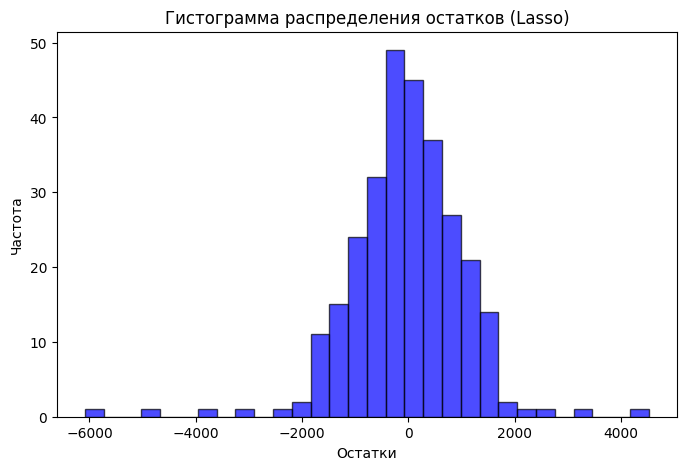

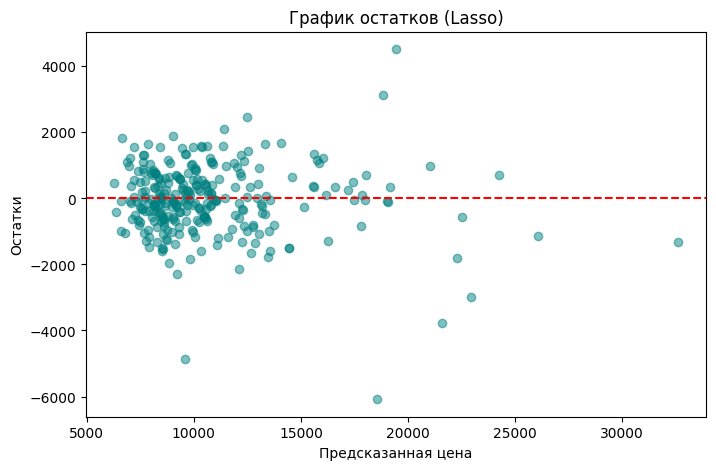

In [334]:
y_test_flat = np.array(y_test).flatten()
y_pred_flat = np.array(y_pred_llr).flatten()

residuals = y_test_flat - y_pred_flat

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, color='blue', alpha=0.7, edgecolor='black')
plt.title('Гистограмма распределения остатков (Lasso)')
plt.xlabel('Остатки')
plt.ylabel('Частота')
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_flat, residuals, alpha=0.5, color='teal')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Предсказанная цена')
plt.ylabel('Остатки')
plt.title('График остатков (Lasso)')
plt.show()

На графиках все хорошо, распределение похоже на нормальное, зависимости ошибки от предсказанной цены не наблюдается. Однако, чтобы быть уверенными, посмотрим статистику Колмогорова-Смирнова и P-значение.

In [336]:
res_std = (residuals - np.mean(residuals)) / np.std(residuals)

ks_statistic, p_value = kstest(res_std, 'norm')

print('Статистика Колмогорова-Смирнова: ', ks_statistic)
print('p-value: ', p_value)

if p_value > 0.05:
    print("Вывод: Остатки распределены нормально.")
else:
    print("Вывод: Остатки НЕ распределены нормально.")

Статистика Колмогорова-Смирнова:  0.05879632121957393
p-value:  0.26196755646232894
Вывод: Остатки распределены нормально.


Как итог, получились неплохие модели, о чем говорят метрики, статистика Колмогорова-Смирнова, р-значение. Лучше всего справилась модель с регуляризацией Lasso.